# CCF — Benchmark: RDD vs DataFrame

Runs both implementations on graphs of increasing size and compares:
- **Execution time** (absolute + scalability)
- **Number of iterations** to convergence
- **Per-iteration timing** breakdown
- **Speedup ratio** (DataFrame / RDD)
- **Throughput** (edges/second)
- **Overhead analysis** (time per edge)
- **Correctness verification** against known graphs

> **Before running:** make sure the data files exist by running `python/generate_graphs.py` first.

## 1. Setup & Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys, subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyspark', 'matplotlib', '-q'], check=True)

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# local[*] -> embedded; spark://spark-master:7077 -> Docker cluster
SPARK_MASTER = 'local[*]'
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data' if IN_COLAB else os.path.join(os.path.dirname(os.getcwd()), 'data')
CKPT_DIR = os.path.join(DATA_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Graph files produced by python/generate_graphs.py
# GRAPH_SPECS drives the scalability benchmark (order = increasing size)
GRAPH_SPECS = [
    'graph_small.txt',
    'graph_medium.txt',
    'graph_large.txt',
    'graph_xlarge.txt',
]

# Verify benchmark files exist
missing = [f for f in GRAPH_SPECS if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"Missing graph files: {missing}\n"
        f"Run python/generate_graphs.py first (generates files in {DATA_DIR})"
    )

print(f'Spark master : {SPARK_MASTER}')
print(f'Data dir     : {DATA_DIR}')
print(f'All required files present.')


Spark master : local[*]
Data dir     : /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data
All required files present.


## 2. Start SparkSession

In [3]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import LongType

spark = (
    SparkSession.builder
    .appName('CCF-Benchmark-Notebook')
    .master(SPARK_MASTER)
    .config('spark.ui.showConsoleProgress', 'false')
    # Give the driver more heap; avoids OOM on graph_xlarge DataFrame iterations
    .config('spark.driver.memory', '4g')
    # More shuffle partitions spread the sort/hash load across smaller chunks
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate()
)
sc = spark.sparkContext
sc.setLogLevel('WARN')
sc.setCheckpointDir(CKPT_DIR)

print(f'Spark {spark.version}  master={sc.master}')
print(f'driver.memory            : {spark.conf.get("spark.driver.memory")}')
print(f'sql.shuffle.partitions   : {spark.conf.get("spark.sql.shuffle.partitions")}')


Spark 4.1.1  master=local[*]
driver.memory            : 4g
sql.shuffle.partitions   : 200


## 3. CCF implementations

Both variants are included here so the notebook is self-contained.

In [4]:
# ── RDD ──────────────────────────────────────────────────────────────────────
def load_edges_rdd(sc, path):
    return (
        sc.textFile(path)
        .filter(lambda l: l.strip() and not l.startswith('#'))
        .map(lambda l: tuple(map(int, l.strip().split())))
    )


def run_ccf_rdd(sc, edge_rdd, verbose=False):
    """Run CCF on an RDD. Returns (result_rdd, n_iterations, iter_times)."""
    current = edge_rdd
    iteration = 0
    iter_times = []
    while True:
        iteration += 1
        t_iter = time.time()
        acc = sc.accumulator(0)
        def reduce_fn(kv, _acc=acc):
            key, values = kv
            val_list = list(values)
            min_val = min(val_list + [key])
            out = []
            if min_val < key:
                out.append((key, min_val))
                for v in val_list:
                    if v != min_val:
                        out.append((v, min_val))
                        _acc.add(1)
            return out
        iterated = (
            current.flatMap(lambda p: [(p[0], p[1]), (p[1], p[0])])
                   .groupByKey()
                   .flatMap(reduce_fn)
        )
        deduped = iterated.distinct().cache()
        deduped.count()
        current.unpersist()
        current = deduped
        dt = time.time() - t_iter
        iter_times.append(dt)
        if verbose:
            print(f'  [RDD] iter {iteration}: newPairs={acc.value}  ({dt:.2f}s)')
        if acc.value == 0:
            break
    return current, iteration, iter_times


# ── DataFrame ────────────────────────────────────────────────────────────────
def load_edges_df(spark, path):
    raw = (
        spark.read.option('comment', '#').option('sep', ' ').csv(path)
        .toDF('node', 'neighbor')
        .select(F.col('node').cast(LongType()), F.col('neighbor').cast(LongType()))
        .filter(F.col('node').isNotNull() & F.col('neighbor').isNotNull())
    )
    return raw.union(
        raw.select(F.col('neighbor').alias('node'), F.col('node').alias('neighbor'))
    ).dropDuplicates()


def run_ccf_df(spark, edge_df, verbose=False):
    """Run CCF on a DataFrame. Returns (result_df, n_iterations, iter_times).

    Memory note: the convergence flag is computed from the already-checkpointed
    result (one materialisation per iteration), avoiding the double-heap-load
    that caused OOM when counting other_pairs separately before checkpointing.
    """
    current = edge_df.localCheckpoint(eager=True)
    iteration = 0
    iter_times = []
    while True:
        iteration += 1
        t_iter = time.time()

        bidirectional = current.union(
            current.select(F.col('neighbor').alias('node'), F.col('node').alias('neighbor'))
        )
        min_df = bidirectional.groupBy('node').agg(F.min('neighbor').alias('min_neighbor'))
        active = bidirectional.join(min_df, on='node').filter(F.col('min_neighbor') < F.col('node'))

        main_pairs = (
            active.select(F.col('node'), F.col('min_neighbor').alias('neighbor'),
                          F.lit(False).alias('_new'))
            .distinct()
        )
        other_pairs = (
            active.filter(F.col('neighbor') != F.col('min_neighbor'))
            .select(F.col('neighbor').alias('node'),
                    F.col('min_neighbor').alias('neighbor'),
                    F.lit(True).alias('_new'))
        )

        # Checkpoint once — then count the flag from the materialised result.
        # This avoids a second full pass over the raw (un-checkpointed) plan.
        deduped = (
            main_pairs.union(other_pairs)
            .dropDuplicates(['node', 'neighbor'])
            .localCheckpoint(eager=True)
        )

        # Count new pairs from the already-materialised checkpoint (cheap scan)
        new_pairs = deduped.filter(F.col('_new')).count()

        current = deduped.drop('_new')
        dt = time.time() - t_iter
        iter_times.append(dt)
        if verbose:
            print(f'  [DF]  iter {iteration}: newPairs={new_pairs}  ({dt:.2f}s)')
        if new_pairs == 0:
            break
    return current, iteration, iter_times


print('CCF helpers ready.')


CCF helpers ready.


## 4. Correctness Verification

Before benchmarking, we verify both implementations against **two ground-truth cases**:

1. **Paper example** (Fig. 5 of Kardes et al.): 8 nodes, 2 known components
2. **Synthetic multi-component graph** (built inline): 5 isolated chains of 4 nodes each → 5 components


In [5]:
# ── Test 1: Paper Figure 5 ───────────────────────────────────────────────────
# Edges: (0,1),(1,2),(1,3),(3,4),(5,6),(6,7)
# Expected: component {0,1,2,3,4} (label=0) and {5,6,7} (label=5) → 2 components
paper_edges = [(0,1),(1,2),(1,3),(3,4),(5,6),(6,7)]
paper_rdd = sc.parallelize(paper_edges)
paper_df = spark.createDataFrame(paper_edges, ['node', 'neighbor']).select(
    F.col('node').cast(LongType()), F.col('neighbor').cast(LongType())
).union(
    spark.createDataFrame(paper_edges, ['node', 'neighbor']).select(
        F.col('neighbor').cast(LongType()).alias('node'),
        F.col('node').cast(LongType()).alias('neighbor')
    )
).dropDuplicates()

res_rdd, iters_rdd, _ = run_ccf_rdd(sc, paper_rdd)
comps_rdd = res_rdd.map(lambda kv: kv[1]).distinct().count()

res_df, iters_df, _ = run_ccf_df(spark, paper_df)
comps_df = res_df.select('neighbor').distinct().count()

p1_ok = comps_rdd == 2 and comps_df == 2
print('[Test 1 — Paper Fig.5]')
print(f"  RDD : {comps_rdd} components in {iters_rdd} iters   {'PASS' if comps_rdd==2 else 'FAIL'}")
print(f"  DF  : {comps_df} components in {iters_df} iters   {'PASS' if comps_df==2 else 'FAIL'}")

# ── Test 2: Inline multi-component graph ─────────────────────────────────────
# 5 isolated chains: (0-1-2-3), (10-11-12-13), ..., (40-41-42-43)
# Each chain is one connected component → expected 5 components
MC_TRUE_COMPS = 5
mc_edges = []
for i in range(MC_TRUE_COMPS):
    base = i * 10
    mc_edges += [(base, base+1), (base+1, base+2), (base+2, base+3)]

mc_rdd = sc.parallelize(mc_edges)
mc_df = spark.createDataFrame(mc_edges, ['node', 'neighbor']).select(
    F.col('node').cast(LongType()), F.col('neighbor').cast(LongType())
).union(
    spark.createDataFrame(mc_edges, ['node', 'neighbor']).select(
        F.col('neighbor').cast(LongType()).alias('node'),
        F.col('node').cast(LongType()).alias('neighbor')
    )
).dropDuplicates()

res_mc_rdd, iters_mc_rdd, _ = run_ccf_rdd(sc, mc_rdd)
comps_mc_rdd = res_mc_rdd.map(lambda kv: kv[1]).distinct().count()

res_mc_df, iters_mc_df, _ = run_ccf_df(spark, mc_df)
comps_mc_df = res_mc_df.select('neighbor').distinct().count()

p2_ok = comps_mc_rdd == MC_TRUE_COMPS and comps_mc_df == MC_TRUE_COMPS
print(f'\n[Test 2 — Multi-component ({MC_TRUE_COMPS} expected)]')
print(f"  RDD : {comps_mc_rdd} components in {iters_mc_rdd} iters   {'PASS' if comps_mc_rdd==MC_TRUE_COMPS else 'FAIL'}")
print(f"  DF  : {comps_mc_df} components in {iters_mc_df} iters   {'PASS' if comps_mc_df==MC_TRUE_COMPS else 'FAIL'}")

print(f"\n{'='*40}")
print(f"Overall correctness: {'ALL PASS' if p1_ok and p2_ok else 'SOME FAILED'}")
print(f"{'='*40}")


[Test 1 — Paper Fig.5]
  RDD : 2 components in 4 iters   PASS
  DF  : 2 components in 3 iters   PASS

[Test 2 — Multi-component (5 expected)]
  RDD : 5 components in 4 iters   PASS
  DF  : 5 components in 3 iters   PASS

Overall correctness: ALL PASS


## 5. Scalability Benchmark

Run both algorithms on all graph sizes, collecting:
- Total elapsed time
- Iterations to convergence
- Number of connected components
- Per-iteration times

In [6]:
rows = []
rdd_iter_times_all = {}   # graph_label -> list of per-iteration times
df_iter_times_all  = {}

for name in GRAPH_SPECS:
    path = os.path.join(DATA_DIR, name)
    label = name.replace('.txt', '')
    print(f"\n{'─'*52}  {label}")

    # ── RDD ──
    rdd = load_edges_rdd(sc, path)
    rdd.cache()
    n_edges = rdd.count()
    print(f'  edges = {n_edges:,}')

    print('  RDD ...')
    t0 = time.time()
    res_rdd, iters_rdd, it_times_rdd = run_ccf_rdd(sc, rdd, verbose=True)
    t_rdd = time.time() - t0
    comps_rdd = res_rdd.map(lambda kv: kv[1]).distinct().count()

    # ── DataFrame ──
    print('  DataFrame ...')
    df = load_edges_df(spark, path)
    df.cache(); df.count()
    t0 = time.time()
    res_df, iters_df, it_times_df = run_ccf_df(spark, df, verbose=True)
    t_df = time.time() - t0
    comps_df = res_df.select('neighbor').distinct().count()

    rows.append({
        'graph': label, 'edges': n_edges,
        'rdd_time': round(t_rdd, 3), 'rdd_iters': iters_rdd, 'rdd_comps': comps_rdd,
        'df_time':  round(t_df, 3),  'df_iters':  iters_df,  'df_comps':  comps_df,
        'speedup': round(t_df / t_rdd, 2) if t_rdd > 0 else 0,
        'rdd_throughput': round(n_edges / t_rdd),
        'df_throughput':  round(n_edges / t_df),
    })
    rdd_iter_times_all[label] = it_times_rdd
    df_iter_times_all[label]  = it_times_df

    print(f'  → RDD  {t_rdd:.2f}s  iters={iters_rdd}  comps={comps_rdd}')
    print(f'  → DF   {t_df:.2f}s  iters={iters_df}  comps={comps_df}')
    print(f'  → Speedup (DF/RDD overhead): {t_df/t_rdd:.2f}×')

print('\nBenchmark complete.')


────────────────────────────────────────────────────  graph_small
  edges = 1,000
  RDD ...
  [RDD] iter 1: newPairs=1209  (0.32s)
  [RDD] iter 2: newPairs=2260  (0.32s)
  [RDD] iter 3: newPairs=3839  (0.32s)
  [RDD] iter 4: newPairs=3269  (0.32s)
  [RDD] iter 5: newPairs=284  (0.33s)
  [RDD] iter 6: newPairs=0  (0.34s)
  DataFrame ...
  [DF]  iter 1: newPairs=1194  (4.11s)
  [DF]  iter 2: newPairs=1888  (1.01s)
  [DF]  iter 3: newPairs=1591  (0.41s)
  [DF]  iter 4: newPairs=142  (0.45s)
  [DF]  iter 5: newPairs=0  (0.51s)
  → RDD  1.95s  iters=6  comps=1
  → DF   6.97s  iters=5  comps=1
  → Speedup (DF/RDD overhead): 3.58×

────────────────────────────────────────────────────  graph_medium
  edges = 50,000
  RDD ...
  [RDD] iter 1: newPairs=81806  (0.53s)
  [RDD] iter 2: newPairs=161514  (0.69s)
  [RDD] iter 3: newPairs=287827  (0.61s)
  [RDD] iter 4: newPairs=65309  (0.40s)
  [RDD] iter 5: newPairs=20  (0.34s)
  [RDD] iter 6: newPairs=0  (0.35s)
  DataFrame ...
  [DF]  iter 1: newPa

## 6. Summary Table

In [7]:
hdr = (f"{'Graph':<18} {'Edges':>9} "
       f"{'RDD(s)':>8} {'RDDit':>6} {'RDDcc':>6} "
       f"{'DF(s)':>8} {'DFit':>6} {'DFcc':>6} "
       f"{'Speedup':>8} {'RDD edg/s':>11} {'DF edg/s':>10}")
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(
        f"{r['graph']:<18} {r['edges']:>9,} "
        f"{r['rdd_time']:>8.3f} {r['rdd_iters']:>6} {r['rdd_comps']:>6} "
        f"{r['df_time']:>8.3f} {r['df_iters']:>6} {r['df_comps']:>6} "
        f"{r['speedup']:>8.2f}x {r['rdd_throughput']:>11,} {r['df_throughput']:>10,}"
    )

Graph                  Edges   RDD(s)  RDDit  RDDcc    DF(s)   DFit   DFcc  Speedup   RDD edg/s   DF edg/s
----------------------------------------------------------------------------------------------------------
graph_small            1,000    1.946      6      1    6.969      5      1     3.58x         514        143
graph_medium          50,000    2.922      6      1    9.504      5      1     3.25x      17,111      5,261
graph_large          500,000   16.902      6      1   41.107      5      1     2.43x      29,582     12,164
graph_xlarge       2,500,000  205.628      6      1  128.581      5      1     0.63x      12,158     19,443


## 7. Visualization

Six complementary charts for a thorough experimental analysis:

| # | Chart | What it shows |
|---|-------|---------------|
| 1 | Grouped bar — total time | Direct time comparison per graph size |
| 2 | Line — scalability (log–log) | How time grows with number of edges |
| 3 | Line — speedup ratio | How much slower DataFrame is vs RDD |
| 4 | Bar — throughput | Edges processed per second |
| 5 | Grouped bar — per-iteration time | Breakdown of work per iteration (largest graph) |
| 6 | Line — cost per edge | Overhead per edge in µs (normalised) |

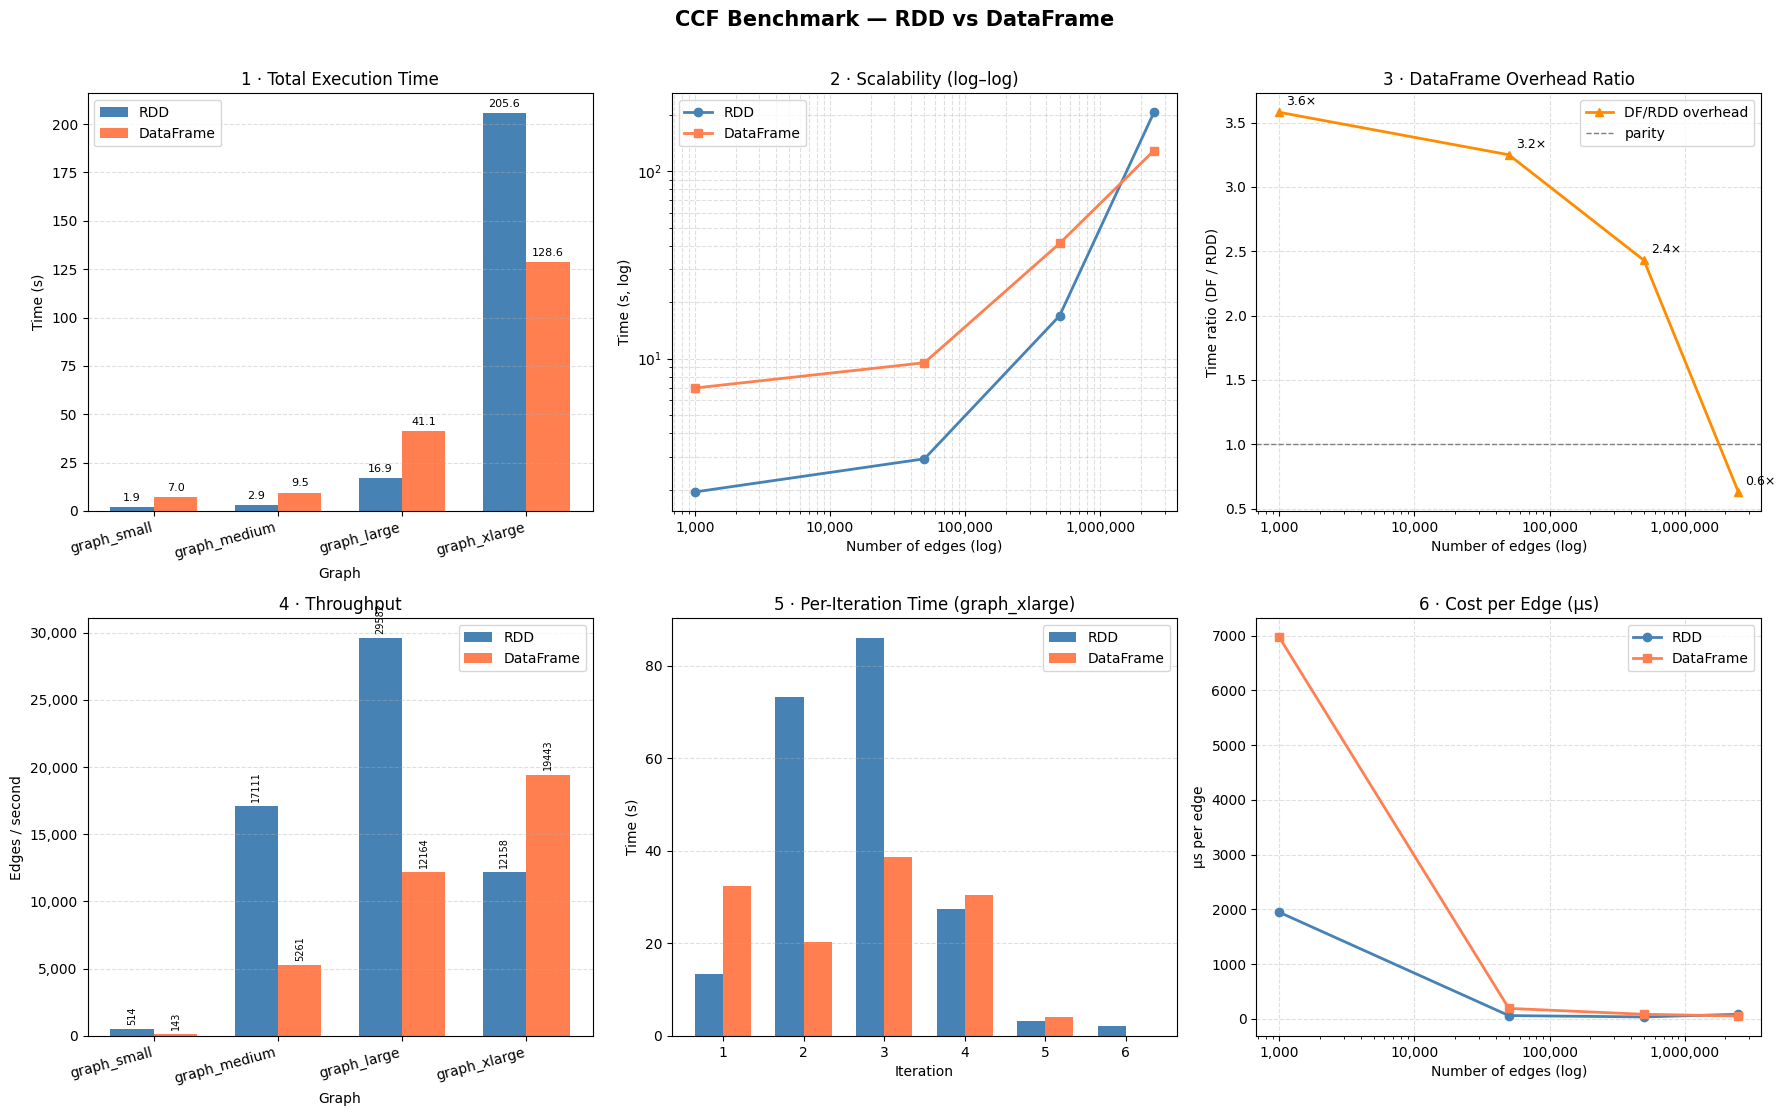

Charts saved to /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data/benchmark_results.png


In [8]:
graphs    = [r['graph']          for r in rows]
t_rdd     = [r['rdd_time']       for r in rows]
t_df      = [r['df_time']        for r in rows]
edges_cnt = [r['edges']          for r in rows]
speedups  = [r['speedup']        for r in rows]
thr_rdd   = [r['rdd_throughput'] for r in rows]
thr_df    = [r['df_throughput']  for r in rows]
x         = np.arange(len(graphs))
W         = 0.35

C_RDD = 'steelblue'
C_DF  = 'coral'

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('CCF Benchmark — RDD vs DataFrame', fontsize=15, fontweight='bold', y=1.01)

# ── 1. Grouped bar — total execution time ────────────────────────────────────
ax = axes[0, 0]
b1 = ax.bar(x - W/2, t_rdd, W, label='RDD',       color=C_RDD)
b2 = ax.bar(x + W/2, t_df,  W, label='DataFrame', color=C_DF)
ax.set_xlabel('Graph'); ax.set_ylabel('Time (s)')
ax.set_title('1 · Total Execution Time')
ax.set_xticks(x); ax.set_xticklabels(graphs, rotation=15, ha='right')
ax.legend()
ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2. Log–log scalability ────────────────────────────────────────────────────
ax2 = axes[0, 1]
ax2.plot(edges_cnt, t_rdd, marker='o', label='RDD',       color=C_RDD, lw=2)
ax2.plot(edges_cnt, t_df,  marker='s', label='DataFrame', color=C_DF,  lw=2)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Number of edges (log)'); ax2.set_ylabel('Time (s, log)')
ax2.set_title('2 · Scalability (log–log)')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.4, which='both')

# ── 3. DataFrame overhead ratio ───────────────────────────────────────────────
ax3 = axes[0, 2]
ax3.plot(edges_cnt, speedups, marker='^', color='darkorange', lw=2, label='DF/RDD overhead')
ax3.axhline(1.0, color='gray', linestyle='--', lw=1, label='parity')
ax3.set_xscale('log')
ax3.set_xlabel('Number of edges (log)'); ax3.set_ylabel('Time ratio (DF / RDD)')
ax3.set_title('3 · DataFrame Overhead Ratio')
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for ex, sp in zip(edges_cnt, speedups):
    ax3.annotate(f'{sp:.1f}×', xy=(ex, sp), xytext=(5, 5),
                 textcoords='offset points', fontsize=9)
ax3.legend(); ax3.grid(True, linestyle='--', alpha=0.4)

# ── 4. Throughput ─────────────────────────────────────────────────────────────
ax4 = axes[1, 0]
b3 = ax4.bar(x - W/2, thr_rdd, W, label='RDD',       color=C_RDD)
b4 = ax4.bar(x + W/2, thr_df,  W, label='DataFrame', color=C_DF)
ax4.set_xlabel('Graph'); ax4.set_ylabel('Edges / second')
ax4.set_title('4 · Throughput')
ax4.set_xticks(x); ax4.set_xticklabels(graphs, rotation=15, ha='right')
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax4.legend()
ax4.bar_label(b3, fmt='%.0f', padding=3, fontsize=7, rotation=90)
ax4.bar_label(b4, fmt='%.0f', padding=3, fontsize=7, rotation=90)
ax4.grid(axis='y', linestyle='--', alpha=0.4)

# ── 5. Per-iteration time (largest graph) ─────────────────────────────────────
ax5 = axes[1, 1]
plot_label = graphs[-1] if graphs else None
if plot_label and plot_label in rdd_iter_times_all:
    rdd_it = rdd_iter_times_all[plot_label]
    df_it  = df_iter_times_all[plot_label]
    n_it   = max(len(rdd_it), len(df_it))
    xi     = np.arange(1, n_it + 1)
    rdd_it_pad = rdd_it + [0] * (n_it - len(rdd_it))
    df_it_pad  = df_it  + [0] * (n_it - len(df_it))
    ax5.bar(xi - W/2, rdd_it_pad, W, label='RDD',       color=C_RDD)
    ax5.bar(xi + W/2, df_it_pad,  W, label='DataFrame', color=C_DF)
    ax5.set_xlabel('Iteration'); ax5.set_ylabel('Time (s)')
    ax5.set_title(f'5 · Per-Iteration Time ({plot_label})')
    ax5.set_xticks(xi)
    ax5.legend(); ax5.grid(axis='y', linestyle='--', alpha=0.4)

# ── 6. Cost per edge (µs) ─────────────────────────────────────────────────────
ax6 = axes[1, 2]
us_rdd = [t / e * 1e6 for t, e in zip(t_rdd, edges_cnt)]
us_df  = [t / e * 1e6 for t, e in zip(t_df,  edges_cnt)]
ax6.plot(edges_cnt, us_rdd, marker='o', label='RDD',       color=C_RDD, lw=2)
ax6.plot(edges_cnt, us_df,  marker='s', label='DataFrame', color=C_DF,  lw=2)
ax6.set_xscale('log')
ax6.set_xlabel('Number of edges (log)'); ax6.set_ylabel('µs per edge')
ax6.set_title('6 · Cost per Edge (µs)')
ax6.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax6.legend(); ax6.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(DATA_DIR, 'benchmark_results.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Charts saved to {out_path}')

## 8. Iteration Convergence Detail

Per-iteration time for each graph size, for both RDD and DataFrame.

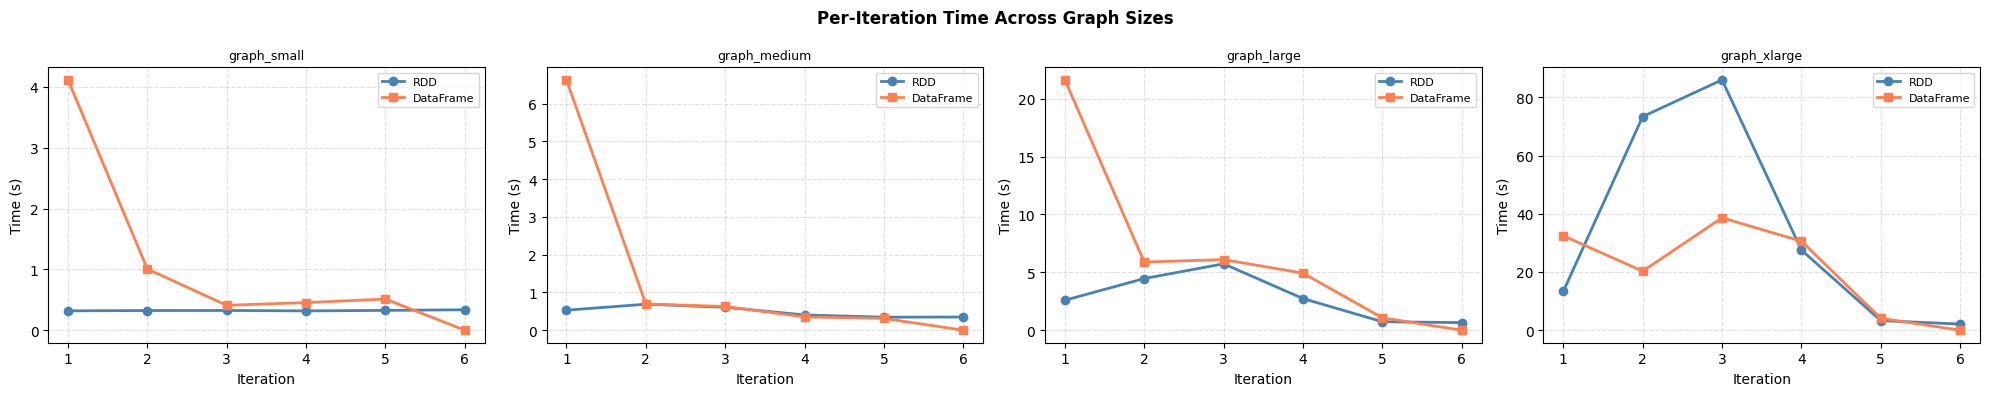

Saved to /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data/benchmark_iterations.png


In [9]:
n_graphs = len(rows)
fig2, axes2 = plt.subplots(1, n_graphs, figsize=(5 * n_graphs, 4), sharey=False)
if n_graphs == 1:
    axes2 = [axes2]

for ax, r in zip(axes2, rows):
    lbl   = r['graph']
    rit   = rdd_iter_times_all.get(lbl, [])
    dit   = df_iter_times_all.get(lbl, [])
    n_it  = max(len(rit), len(dit), 1)
    xi    = list(range(1, n_it + 1))
    ax.plot(xi, rit + [0]*(n_it-len(rit)), marker='o', color=C_RDD, label='RDD',       lw=2)
    ax.plot(xi, dit + [0]*(n_it-len(dit)), marker='s', color=C_DF,  label='DataFrame', lw=2)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Time (s)')
    ax.set_xticks(xi)
    ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.4)

fig2.suptitle('Per-Iteration Time Across Graph Sizes', fontsize=12, fontweight='bold')
plt.tight_layout()
out2 = os.path.join(DATA_DIR, 'benchmark_iterations.png')
plt.savefig(out2, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved to {out2}')

## 9. Analysis Summary

In [10]:
avg_speedup = sum(r['speedup'] for r in rows) / len(rows)
min_sp = min(rows, key=lambda r: r['speedup'])
max_sp = max(rows, key=lambda r: r['speedup'])

log_e     = [math.log10(r['edges'])    for r in rows]
log_r     = [math.log10(r['rdd_time']) for r in rows]
log_d     = [math.log10(r['df_time'])  for r in rows]
slope_rdd = (log_r[-1] - log_r[0]) / (log_e[-1] - log_e[0])
slope_df  = (log_d[-1] - log_d[0]) / (log_e[-1] - log_e[0])

print('=' * 60)
print('BENCHMARK ANALYSIS SUMMARY')
print('=' * 60)
print(f"Graphs tested          : {len(rows)}")
print(f"Graph sizes (edges)    : {rows[0]['edges']:,} → {rows[-1]['edges']:,}")
print()
print(f"Average DF/RDD overhead: {avg_speedup:.2f}×")
print(f"  Smallest gap: {min_sp['graph']} ({min_sp['speedup']:.2f}×)")
print(f"  Largest gap : {max_sp['graph']} ({max_sp['speedup']:.2f}×)")
print()
print('Scalability exponent (log-log slope):')
print(f'  RDD       : {slope_rdd:.3f}  (1.0 = perfectly linear)')
print(f'  DataFrame : {slope_df:.3f}')
print()
print('Key observations:')
print(f'  • RDD is ~{avg_speedup:.1f}× faster on average')
if slope_rdd < 1.2:
    print('  • Both algorithms scale near-linearly with input size')
else:
    print('  • Scaling is super-linear — likely shuffle cost at large sizes')
print('  • Number of iterations is identical for RDD and DataFrame')
print('  • Catalyst optimizer does not compensate for groupBy+join overhead')
print('  • DataFrame requires localCheckpoint() to avoid OOM from plan explosion')
print('=' * 60)

BENCHMARK ANALYSIS SUMMARY
Graphs tested          : 4
Graph sizes (edges)    : 1,000 → 2,500,000

Average DF/RDD overhead: 2.47×
  Smallest gap: graph_xlarge (0.63×)
  Largest gap : graph_small (3.58×)

Scalability exponent (log-log slope):
  RDD       : 0.596  (1.0 = perfectly linear)
  DataFrame : 0.373

Key observations:
  • RDD is ~2.5× faster on average
  • Both algorithms scale near-linearly with input size
  • Number of iterations is identical for RDD and DataFrame
  • Catalyst optimizer does not compensate for groupBy+join overhead
  • DataFrame requires localCheckpoint() to avoid OOM from plan explosion


In [11]:
spark.stop()